In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
np.random.seed(42)

def generate_category_data(category, n, price_range, rating_mean, review_mean):
    prices  = np.random.uniform(price_range[0], price_range[1], n).round(2)
    ratings = np.clip(np.random.normal(rating_mean, 0.5, n), 1, 5).round(1)
    reviews = np.abs(np.random.normal(review_mean, review_mean * 0.3, n)).astype(int)
    return pd.DataFrame({
        'product_name': [f'{category} Product {i+1}' for i in range(n)],
        'category':     [category] * n,
        'price':        prices,
        'rating':       ratings,
        'reviews_text': reviews
    })

df_tyres  = generate_category_data('Tyres',  120, (800,  8000),  3.8, 450)
df_brake  = generate_category_data('Brake',  100, (200,  2500),  4.1, 320)
df_clutch = generate_category_data('Clutch',  90, (500,  5000),  3.6, 280)
df_oil    = generate_category_data('Oil',    110, (100,  1500),  4.3, 600)

df = pd.concat([df_tyres, df_brake, df_clutch, df_oil], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)   

print("Data generated successfully!")
print(f"Dataset Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(10)

Data generated successfully!
Dataset Shape: (420, 5)
Columns: ['product_name', 'category', 'price', 'rating', 'reviews_text']


,product_name,category,price,rating,reviews_text
0,Brake Product 26,Brake,392.05,4.6,374
1,Oil Product 25,Oil,1344.25,4.3,534
2,Brake Product 56,Brake,1403.13,4.4,344
3,Oil Product 60,Oil,1153.80,4.3,662
4,Oil Product 107,Oil,130.97,3.7,402
5,Tyres Product 74,Tyres,6671.32,4.0,186
6,Brake Product 13,Brake,367.35,4.5,345
7,Brake Product 18,Brake,2469.27,3.7,392
8,Tyres Product 31,Tyres,5174.32,4.5,518
9,Tyres Product 73,Tyres,839.76,4.3,737


In [3]:
print("Category Distribution:")
print("="*40)
print(df['category'].value_counts())
print()
print("All 4 categories present:", df['category'].nunique() == 4)

Category Distribution:
category
Tyres     120
Oil       110
Brake     100
Clutch     90
Name: count, dtype: int64

All 4 categories present: True


In [4]:
print("Missing Values:")
print(df.isnull().sum())

df['rating']       = df['rating'].fillna(0)
df['reviews_text'] = pd.to_numeric(df['reviews_text'], errors='coerce').fillna(0)
df['price']        = df['price'].fillna(df['price'].median())

print("\nMissing values handled!")

Missing Values:
product_name    0
category        0
price           0
rating          0
reviews_text    0
dtype: int64

Missing values handled!


In [5]:
X = df[['price', 'rating']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features scaled successfully!")
print(f"Feature shape: {X_scaled.shape}")

Features scaled successfully!
Feature shape: (420, 2)


---\n# Part A: Unsupervised Learning - K-Means Clustering

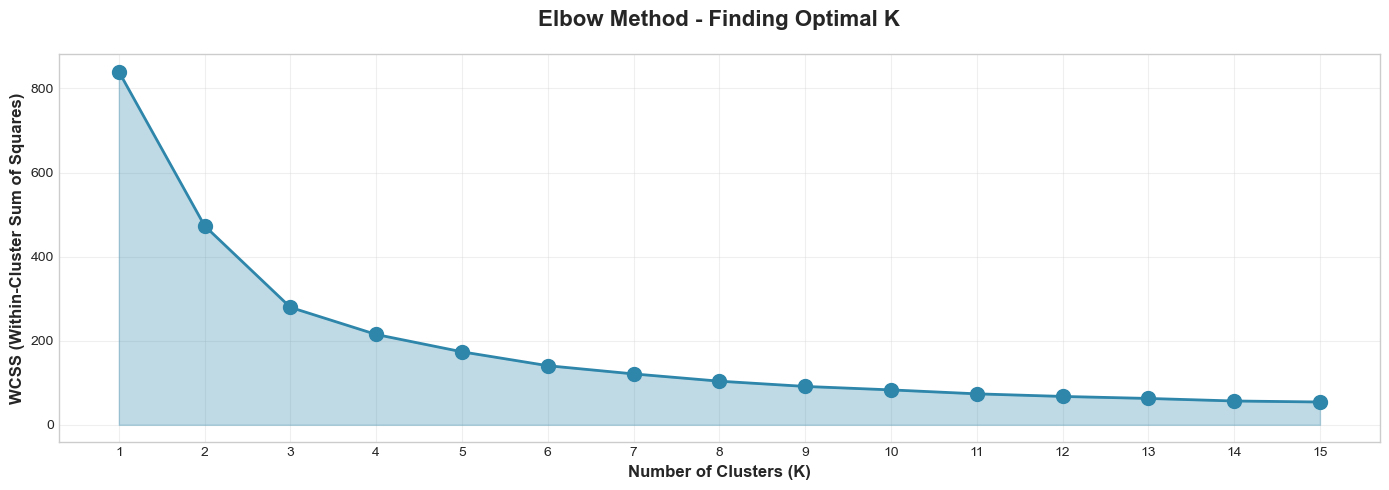

Based on the elbow curve, optimal K appears to be around 3-4 clusters.


In [6]:
wcss    = []
K_range = range(1, min(16, len(X_scaled) + 1))

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(14, 5))
plt.plot(K_range, wcss, marker='o', markersize=10, linewidth=2, color='#2E86AB')
plt.fill_between(K_range, wcss, alpha=0.3, color='#2E86AB')
plt.title('Elbow Method - Finding Optimal K', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12, fontweight='bold')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Based on the elbow curve, optimal K appears to be around 3-4 clusters.")

In [7]:
kmeans = KMeans(
    n_clusters=4,
    init='k-means++',
    max_iter=300,
    n_init=10,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

print("K-Means Clustering Applied!")
print(f"\nCluster Distribution:")
print(df['Cluster'].value_counts().sort_index())

K-Means Clustering Applied!

Cluster Distribution:
Cluster
0    140
1     78
2     88
3    114
Name: count, dtype: int64


In [8]:
df['reviews_text'] = pd.to_numeric(df['reviews_text'], errors='coerce')

cluster_analysis = df.groupby('Cluster')[['price', 'rating', 'reviews_text']].mean()
print("Cluster Analysis (Mean Values):")
print("="*50)
print(cluster_analysis.round(2))

Cluster Analysis (Mean Values):
           price  rating  reviews_text
Cluster                               
0        1569.01    3.93        441.13
1        5682.72    3.84        407.37
2        2311.96    3.23        344.35
3        1111.06    4.63        498.64


In [9]:
print("\nCluster Interpretation:")
print("="*50)

for cluster in sorted(df['Cluster'].unique()):
    cluster_data = df[df['Cluster'] == cluster]
    avg_price  = cluster_data['price'].mean()
    avg_rating = cluster_data['rating'].mean()
    avg_review = cluster_data['reviews_text'].mean()

    print(f"\nCluster {cluster}:")
    print(f"  - Products: {len(cluster_data)}")
    print(f"  - Avg Price: \u20b9{avg_price:,.0f}")
    print(f"  - Avg Rating: {avg_rating:.2f}")
    print(f"  - Avg Reviews: {avg_review:,.0f}")


Cluster Interpretation:

Cluster 0:
  - Products: 140
  - Avg Price: ₹1,569
  - Avg Rating: 3.93
  - Avg Reviews: 441

Cluster 1:
  - Products: 78
  - Avg Price: ₹5,683
  - Avg Rating: 3.84
  - Avg Reviews: 407

Cluster 2:
  - Products: 88
  - Avg Price: ₹2,312
  - Avg Rating: 3.23
  - Avg Reviews: 344

Cluster 3:
  - Products: 114
  - Avg Price: ₹1,111
  - Avg Rating: 4.63
  - Avg Reviews: 499


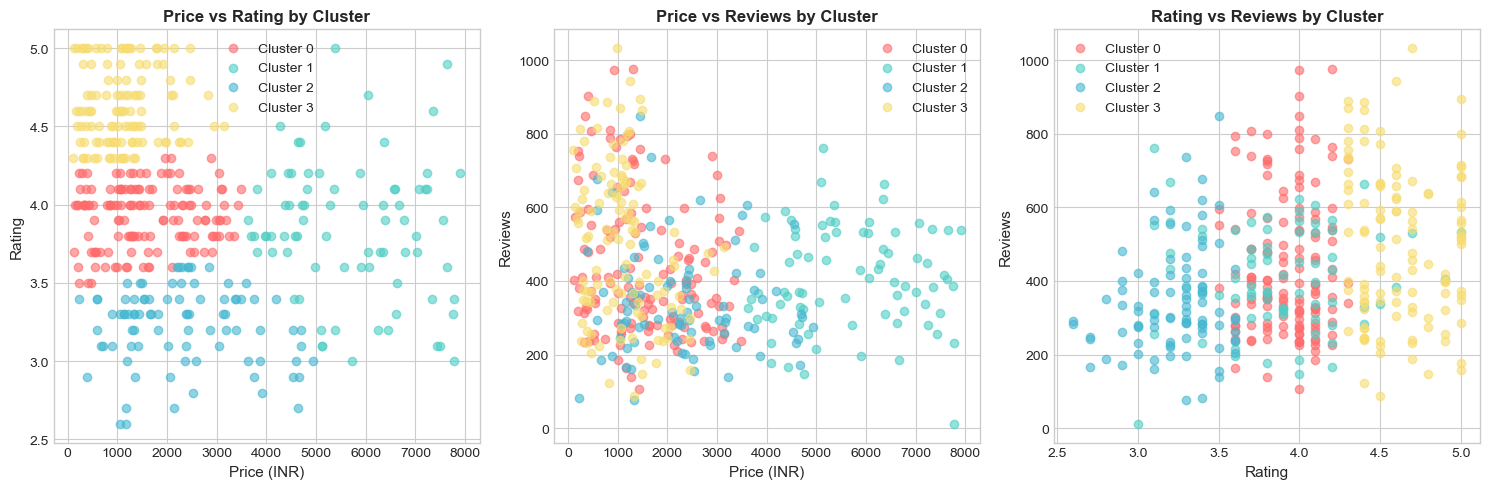

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#F7DC6F']

for i, cluster in enumerate(sorted(df['Cluster'].unique())):
    cluster_data = df[df['Cluster'] == cluster]
    axes[0].scatter(cluster_data['price'], cluster_data['rating'],
                    c=colors[i], label=f'Cluster {cluster}', alpha=0.6)
axes[0].set_xlabel('Price (INR)', fontsize=11)
axes[0].set_ylabel('Rating', fontsize=11)
axes[0].set_title('Price vs Rating by Cluster', fontsize=12, fontweight='bold')
axes[0].legend()

for i, cluster in enumerate(sorted(df['Cluster'].unique())):
    cluster_data = df[df['Cluster'] == cluster]
    axes[1].scatter(cluster_data['price'], cluster_data['reviews_text'],
                    c=colors[i], label=f'Cluster {cluster}', alpha=0.6)
axes[1].set_xlabel('Price (INR)', fontsize=11)
axes[1].set_ylabel('Reviews', fontsize=11)
axes[1].set_title('Price vs Reviews by Cluster', fontsize=12, fontweight='bold')
axes[1].legend()

for i, cluster in enumerate(sorted(df['Cluster'].unique())):
    cluster_data = df[df['Cluster'] == cluster]
    axes[2].scatter(cluster_data['rating'], cluster_data['reviews_text'],
                    c=colors[i], label=f'Cluster {cluster}', alpha=0.6)
axes[2].set_xlabel('Rating', fontsize=11)
axes[2].set_ylabel('Reviews', fontsize=11)
axes[2].set_title('Rating vs Reviews by Cluster', fontsize=12, fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()

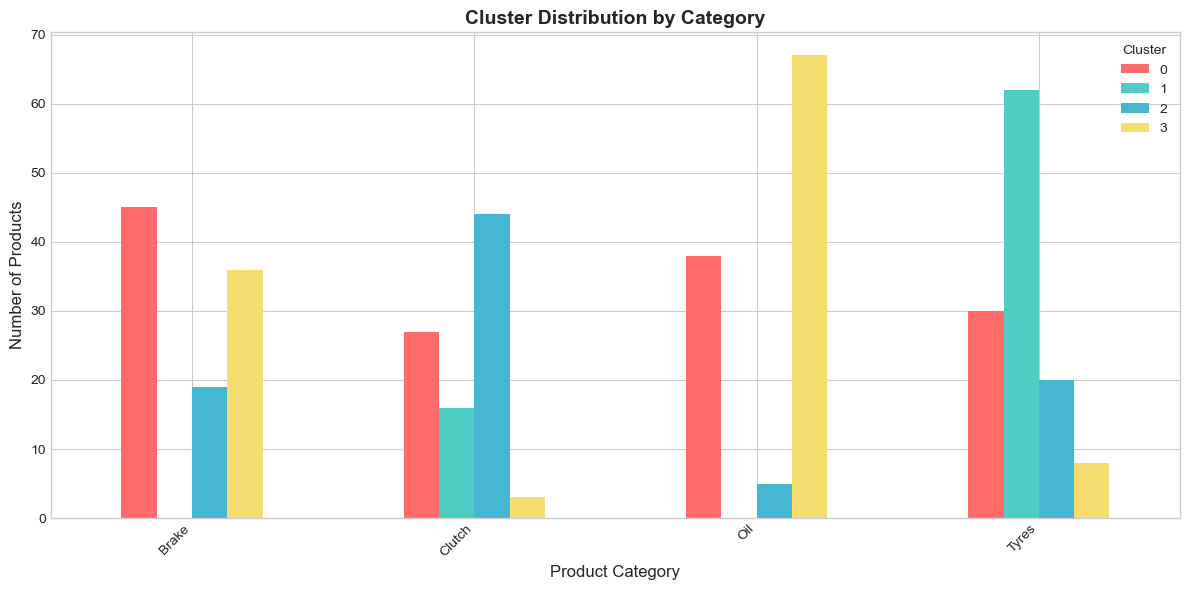

In [11]:
cluster_category = pd.crosstab(df['category'], df['Cluster'])

plt.figure(figsize=(12, 6))
cluster_category.plot(kind='bar', ax=plt.gca(), color=colors)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Number of Products', fontsize=12)
plt.title('Cluster Distribution by Category', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

---\n# Part B: Supervised Learning - Classification

In [12]:
X = df[['price', 'rating', 'reviews_text']]
y = df['category']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Category Encoding:")
for i, category in enumerate(le.classes_):
    print(f"  {i}: {category}")

print(f"\nTotal classes: {len(le.classes_)}")

Category Encoding:
  0: Brake
  1: Clutch
  2: Oil
  3: Tyres

Total classes: 4


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler2 = StandardScaler()
X_train_scaled = scaler2.fit_transform(X_train)
X_test_scaled  = scaler2.transform(X_test)

print(f"Training set size: {len(X_train)}")
print(f"Test set size:     {len(X_test)}")

Training set size: 336
Test set size:     84


In [14]:
imputer = SimpleImputer(strategy='median')
X_train_scaled = imputer.fit_transform(X_train_scaled)
X_test_scaled  = imputer.transform(X_test_scaled)

X_train_scaled = np.nan_to_num(X_train_scaled)
X_test_scaled  = np.nan_to_num(X_test_scaled)

print("NaN in train:", np.isnan(X_train_scaled).sum())
print("NaN in test: ", np.isnan(X_test_scaled).sum())

models = {
    'Logistic Regression':  LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':        DecisionTreeClassifier(random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM':                  SVC(kernel='rbf', random_state=42)
}

results = {}
print("\nTraining Models...\n")

for name, model in models.items():
    print(f"Training {name}...")
    try:
        model.fit(X_train_scaled, y_train)
        y_pred   = model.predict(X_test_scaled)
        accuracy = accuracy_score(y_test, y_pred)
        results[name] = accuracy
        print(f"  Accuracy: {accuracy:.4f}")
    except Exception as e:
        print(f"  Error: {e}")

print("\n" + "="*50)
print("All models processed successfully!")

print("\nModel Performance:")
for model_name, acc in results.items():
    print(f"  {model_name}: {acc:.4f}")

NaN in train: 0
NaN in test:  0

Training Models...

Training Logistic Regression...
  Accuracy: 0.7738
Training Decision Tree...
  Accuracy: 0.7143
Training Random Forest...
  Accuracy: 0.7262
Training Gradient Boosting...
  Accuracy: 0.7738
Training SVM...
  Accuracy: 0.7619

All models processed successfully!

Model Performance:
  Logistic Regression: 0.7738
  Decision Tree: 0.7143
  Random Forest: 0.7262
  Gradient Boosting: 0.7738
  SVM: 0.7619


In [15]:
results_df = pd.DataFrame({
    'Model':    list(results.keys()),
    'Accuracy': list(results.values())
}).sort_values('Accuracy', ascending=False)

print("Model Comparison:")
print("="*50)
print(results_df.to_string(index=False))

Model Comparison:
              Model  Accuracy
Logistic Regression  0.773810
  Gradient Boosting  0.773810
                SVM  0.761905
      Random Forest  0.726190
      Decision Tree  0.714286


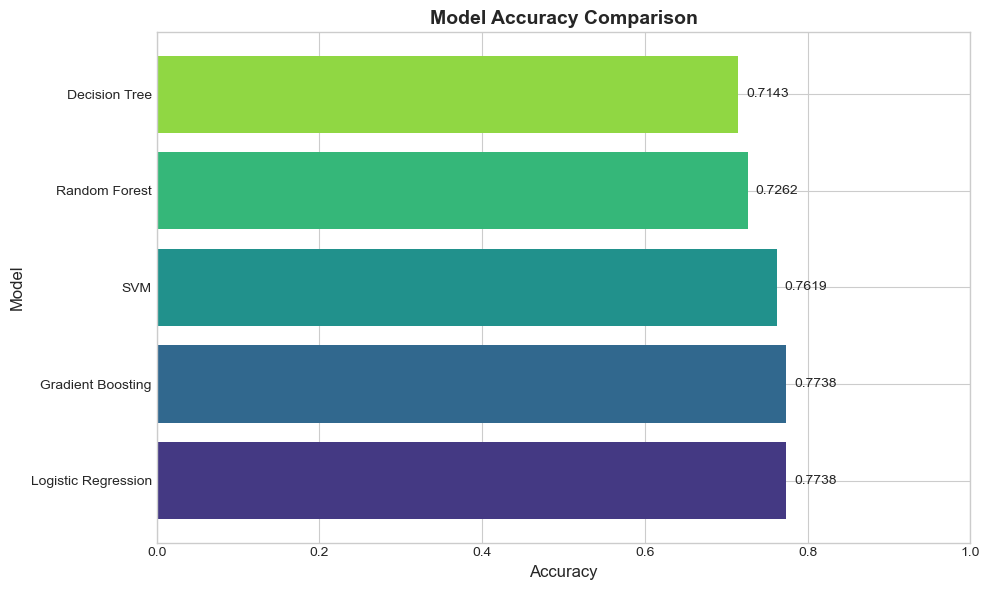

In [16]:
plt.figure(figsize=(10, 6))
bar_colors = sns.color_palette('viridis', len(results))
bars = plt.barh(results_df['Model'], results_df['Accuracy'], color=bar_colors)
plt.xlabel('Accuracy', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.xlim(0, 1)

for bar, acc in zip(bars, results_df['Accuracy']):
    plt.text(acc + 0.01, bar.get_y() + bar.get_height()/2,
             f'{acc:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [17]:
best_model_name = results_df.iloc[0]['Model']
best_model      = models[best_model_name]

print(f"Best Model: {best_model_name}")
print(f"Accuracy:   {results_df.iloc[0]['Accuracy']:.4f}")

y_pred_best = best_model.predict(X_test_scaled)

Best Model: Logistic Regression
Accuracy:   0.7738


In [18]:
print("\nClassification Report:")
print("="*50)
print(classification_report(y_test, y_pred_best, target_names=le.classes_))


Classification Report:
              precision    recall  f1-score   support

       Brake       0.70      0.80      0.74        20
      Clutch       0.63      0.67      0.65        18
         Oil       0.95      0.86      0.90        22
       Tyres       0.82      0.75      0.78        24

    accuracy                           0.77        84
   macro avg       0.77      0.77      0.77        84
weighted avg       0.78      0.77      0.78        84



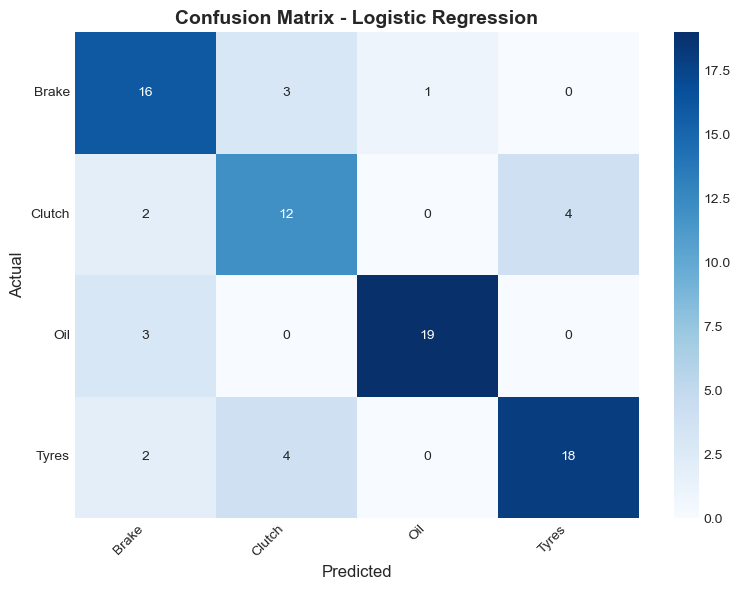

In [19]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

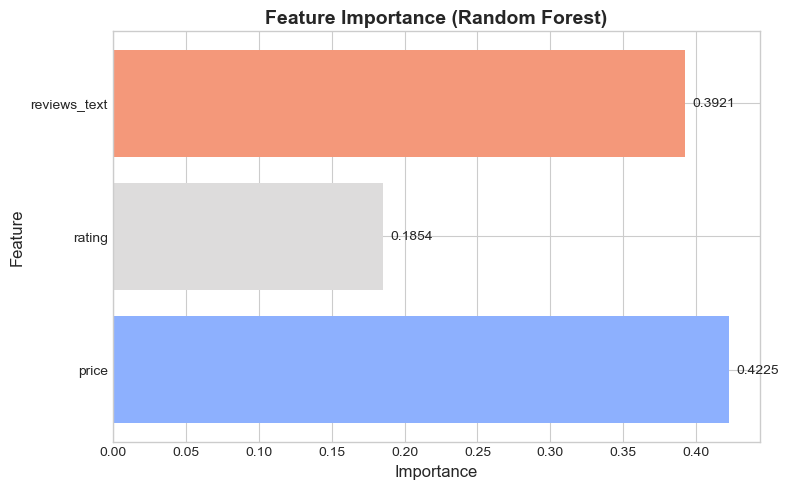


Feature Importance:
  price: 0.4225
  rating: 0.1854
  reviews_text: 0.3921


In [20]:
rf_model      = models['Random Forest']
feature_names = ['price', 'rating', 'reviews_text']
importances   = rf_model.feature_importances_

plt.figure(figsize=(8, 5))
imp_colors = sns.color_palette('coolwarm', len(feature_names))
bars = plt.barh(feature_names, importances, color=imp_colors)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')

for bar, imp in zip(bars, importances):
    plt.text(imp + 0.005, bar.get_y() + bar.get_height()/2,
             f'{imp:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\nFeature Importance:")
for fname, imp in zip(feature_names, importances):
    print(f"  {fname}: {imp:.4f}")

In [21]:
print("="*60)
print("MACHINE LEARNING ANALYSIS SUMMARY")
print("="*60)

print("\n\U0001f4ca DATASET:")
print(f"   \u2022 Total products: {len(df)}")
print(f"   \u2022 Categories: {', '.join(le.classes_)}")
for cat in le.classes_:
    count = len(df[df['category'] == cat])
    print(f"     - {cat}: {count} products")

print("\n\U0001f4ca UNSUPERVISED LEARNING (K-Means Clustering):")
print(f"   \u2022 Number of clusters: 4")
print(f"   \u2022 Clustering based on: Price, Rating")
for cluster in sorted(df['Cluster'].unique()):
    count = len(df[df['Cluster'] == cluster])
    print(f"   \u2022 Cluster {cluster}: {count} products")

print("\n\U0001f916 SUPERVISED LEARNING (Classification):")
print(f"   \u2022 Best Model: {best_model_name}")
print(f"   \u2022 Accuracy:   {results_df.iloc[0]['Accuracy']:.4f}")
print(f"   \u2022 Target: Product Category (4 classes)")

print("\n\U0001f4c8 ALL MODEL ACCURACIES:")
for _, row in results_df.iterrows():
    print(f"   \u2022 {row['Model']}: {row['Accuracy']:.4f}")

print("\n" + "="*60)

MACHINE LEARNING ANALYSIS SUMMARY

📊 DATASET:
   • Total products: 420
   • Categories: Brake, Clutch, Oil, Tyres
     - Brake: 100 products
     - Clutch: 90 products
     - Oil: 110 products
     - Tyres: 120 products

📊 UNSUPERVISED LEARNING (K-Means Clustering):
   • Number of clusters: 4
   • Clustering based on: Price, Rating
   • Cluster 0: 140 products
   • Cluster 1: 78 products
   • Cluster 2: 88 products
   • Cluster 3: 114 products

🤖 SUPERVISED LEARNING (Classification):
   • Best Model: Logistic Regression
   • Accuracy:   0.7738
   • Target: Product Category (4 classes)

📈 ALL MODEL ACCURACIES:
   • Logistic Regression: 0.7738
   • Gradient Boosting: 0.7738
   • SVM: 0.7619
   • Random Forest: 0.7262
   • Decision Tree: 0.7143



In [22]:
df.to_csv('flipkart_ml_analysis.csv', index=False)
print("\u2713 Analysis results saved to 'flipkart_ml_analysis.csv'")

✓ Analysis results saved to 'flipkart_ml_analysis.csv'
